# DiT-Base - Binary Classification - 15K Driver's License Dataset

**Goal:** Train DiT-Base (microsoft/dit-base) pre-trained on 42M document images for binary forgery detection. Compare with ViT-Small (ImageNet) to evaluate if document-specific pre-training improves forgery detection.

## Dataset
- **15,000 images** = 7,500 Real + 7,500 Fake
- **2,500 subjects per country** (WV, DC, AZ)
- Train: 12,000 | Val: 1,500 | Test: 1,500
- test_samples.json subjects EXCLUDED (reserved for out-of-dataset eval)

## Architecture

| Setting | Value |
|---------|-------|
| **Model** | DiT-Base (768-dim, 86M params) |
| **Pre-training** | IIT-CDIP (42M document images) |
| **Loss** | Focal Loss (gamma=2.0) |
| **Augmentation** | Light (preserve forgery artifacts) |
| **Training** | 3-stage gradual unfreezing |
| **Head** | MLP (LayerNorm → Linear → GELU → Dropout → Linear) |
| **TTA** | 4 augmented views |

## Setup

In [1]:
import os
import sys

project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/roy-siftt/final-project


In [2]:
%pip install -q huggingface_hub


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from huggingface_hub import hf_hub_download
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## Load Data (15K Dataset)

In [4]:
data_dir = "notebooks/drivers_license_forgery/production/data"
dataset_root = "datasets/drivers_license_15k"

train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")
print(f"\nTrain balance: Real={len(train_df[train_df['is_fake']==0])}, Fake={len(train_df[train_df['is_fake']==1])}")
print(f"Val balance:   Real={len(val_df[val_df['is_fake']==0])}, Fake={len(val_df[val_df['is_fake']==1])}")
print(f"Test balance:  Real={len(test_df[test_df['is_fake']==0])}, Fake={len(test_df[test_df['is_fake']==1])}")

Train: 12000 | Val: 1500 | Test: 1500
Total: 15000

Train balance: Real=6000, Fake=6000
Val balance:   Real=750, Fake=750
Test balance:  Real=750, Fake=750


## Focal Loss

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance and hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal Loss defined (gamma=2.0 focuses on hard examples)")

Focal Loss defined (gamma=2.0 focuses on hard examples)


## Lighter Augmentation Strategy

Preserve forgery artifacts, minimal blur/noise, NO CoarseDropout.

In [6]:
# LIGHTER augmentation - preserve forgery artifacts
train_transform = A.Compose([
    A.Resize(224, 224),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=0,
        p=0.5
    ),
    A.Perspective(
        scale=(0.02, 0.05),
        p=0.2
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.1
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

# Test-Time Augmentation transforms
tta_transforms = [
    val_test_transform,
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(0.95, 0.95), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(1.05, 1.05), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

print("Augmentation strategy:")
print("  - LIGHTER transforms to preserve forgery artifacts")
print("  - NO CoarseDropout (can hide forgery regions)")
print("  - Minimal blur/noise (artifacts are in fine details)")
print("  - TTA: 4 augmented views for evaluation")

Augmentation strategy:
  - LIGHTER transforms to preserve forgery artifacts
  - NO CoarseDropout (can hide forgery regions)
  - Minimal blur/noise (artifacts are in fine details)
  - TTA: 4 augmented views for evaluation


## Dataset Class

In [7]:
class BinaryForgeryDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform is not None:
            transformed = self.transform(image=img_np)
            img = transformed['image']

        is_fake = int(row['is_fake'])
        return img, torch.tensor(is_fake, dtype=torch.long)

# Create datasets
train_dataset = BinaryForgeryDataset(train_df, dataset_root, train_transform)
val_dataset = BinaryForgeryDataset(val_df, dataset_root, val_test_transform)
test_dataset = BinaryForgeryDataset(test_df, dataset_root, val_test_transform)

# Dataloaders - batch_size=32 (DiT-Base is 4x larger than ViT-Small)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Batch size: 32")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Batch size: 32
Train batches: 375 | Val batches: 47 | Test batches: 47


## DiT-Base Model with MLP Head

In [8]:
class DiTBinaryClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.1):
        super(DiTBinaryClassifier, self).__init__()
        
        # Use timm ViT-Base with layer scale (same architecture as DiT-Base)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0, init_values=1e-5)
        self._load_dit_weights()
        num_features = 768
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, num_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_features // 2, num_classes)
        )
        
        print(f"Model: DiT-Base (microsoft/dit-base) via timm")
        print(f"  - Pre-training: IIT-CDIP (42M document images)")
        print(f"  - Embedding dim: {num_features}")
        print(f"  - MLP head: {num_features} -> {num_features//2} -> {num_classes}")
        print(f"  - Dropout: {dropout}")
        print(f"  - Total params: {sum(p.numel() for p in self.parameters()):,}")
    
    def _load_dit_weights(self):
        weights_path = hf_hub_download(repo_id='microsoft/dit-base', filename='pytorch_model.bin')
        dit_state = torch.load(weights_path, map_location='cpu', weights_only=True)
        converted = self._convert_dit_to_timm(dit_state)
        self.backbone.load_state_dict(converted, strict=True)
        print(f"  - DiT weights loaded: {len(converted)} keys matched")
    
    @staticmethod
    def _convert_dit_to_timm(dit_state_dict):
        """Convert HuggingFace DiT/BEiT state dict to timm ViT format."""
        new_state = {}
        for key, value in dit_state_dict.items():
            k = key.replace('beit.', '') if key.startswith('beit.') else key
            if k in ('embeddings.mask_token',): continue
            if k.startswith('layernorm.'):
                new_state[k.replace('layernorm.', 'norm.')] = value; continue
            if k.startswith('classifier.') or k.startswith('lm_head.'): continue
            if k == 'embeddings.cls_token':
                new_state['cls_token'] = value; continue
            if k == 'embeddings.position_embeddings':
                new_state['pos_embed'] = value; continue
            if k.startswith('embeddings.patch_embeddings.projection.'):
                new_state[k.replace('embeddings.patch_embeddings.projection.', 'patch_embed.proj.')] = value; continue
            if k.startswith('encoder.layer.'):
                rest = k[len('encoder.layer.'):]
                layer_idx = rest.split('.')[0]
                layer_rest = rest[len(layer_idx) + 1:]
                prefix = f'blocks.{layer_idx}'
                if layer_rest == 'attention.attention.query.weight':
                    new_state[f'{prefix}.attn.q.weight'] = value; continue
                if layer_rest == 'attention.attention.key.weight':
                    new_state[f'{prefix}.attn.k.weight'] = value; continue
                if layer_rest == 'attention.attention.value.weight':
                    new_state[f'{prefix}.attn.v.weight'] = value; continue
                if layer_rest == 'attention.attention.query.bias':
                    new_state[f'{prefix}.attn.q.bias'] = value; continue
                if layer_rest == 'attention.attention.value.bias':
                    new_state[f'{prefix}.attn.v.bias'] = value; continue
                if layer_rest.startswith('attention.output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.attn.proj.{suffix}'] = value; continue
                if layer_rest.startswith('intermediate.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc1.{suffix}'] = value; continue
                if layer_rest.startswith('output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc2.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_before.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm1.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_after.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm2.{suffix}'] = value; continue
                if layer_rest == 'lambda_1':
                    new_state[f'{prefix}.ls1.gamma'] = value; continue
                if layer_rest == 'lambda_2':
                    new_state[f'{prefix}.ls2.gamma'] = value; continue

        # Fuse Q, K, V weights and biases
        import torch
        fused_state = {}
        q_weight_keys = sorted([k for k in new_state if '.attn.q.weight' in k])
        for q_key in q_weight_keys:
            bp = q_key.replace('.attn.q.weight', '')
            q_w = new_state[f'{bp}.attn.q.weight']
            k_w = new_state[f'{bp}.attn.k.weight']
            v_w = new_state[f'{bp}.attn.v.weight']
            fused_state[f'{bp}.attn.qkv.weight'] = torch.cat([q_w, k_w, v_w], dim=0)
            q_b = new_state[f'{bp}.attn.q.bias']
            v_b = new_state[f'{bp}.attn.v.bias']
            k_b = torch.zeros_like(q_b)
            fused_state[f'{bp}.attn.qkv.bias'] = torch.cat([q_b, k_b, v_b], dim=0)

        skip = ('.attn.q.weight', '.attn.k.weight', '.attn.v.weight', '.attn.q.bias', '.attn.v.bias')
        for k, v in new_state.items():
            if not any(k.endswith(s) for s in skip):
                fused_state[k] = v
        return fused_state
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone FROZEN")
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")
    
    def unfreeze_last_n_blocks(self, n=4):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        for block in self.backbone.blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        for param in self.backbone.norm.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Last {n} transformer blocks UNFROZEN ({trainable:,}/{total:,} trainable)")

model = DiTBinaryClassifier(num_classes=2).to(device)

  - DiT weights loaded: 174 keys matched
Model: DiT-Base (microsoft/dit-base) via timm
  - Pre-training: IIT-CDIP (42M document images)
  - Embedding dim: 768
  - MLP head: 768 -> 384 -> 2
  - Dropout: 0.1
  - Total params: 86,114,690


## Training with 3-Stage Unfreezing + OneCycleLR

1. **Stage 1 (10 epochs):** Train only classifier head
2. **Stage 2 (15 epochs):** Unfreeze last 4 transformer blocks
3. **Stage 3 (25 epochs):** Full fine-tuning with lower LR

In [9]:
# Loss function
criterion = FocalLoss(alpha=1.0, gamma=2.0)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

# Best model tracking
best_val_acc = 0.0
best_model_state = None
best_epoch = 0

max_grad_norm = 1.0

def evaluate(loader, use_tta=False):
    model.eval()
    
    if not use_tta:
        total, correct = 0, 0
        loss_total = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss_total += loss.item()
                
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return {
            'acc': correct / total,
            'loss': loss_total / len(loader),
            'preds': all_preds,
            'labels': all_labels
        }
    else:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in loader:
                batch_probs = []
                imgs_np = imgs.numpy().transpose(0, 2, 3, 1)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                imgs_np = (imgs_np * std + mean) * 255
                imgs_np = imgs_np.astype(np.uint8)
                
                for tta_transform in tta_transforms:
                    tta_imgs = []
                    for img in imgs_np:
                        transformed = tta_transform(image=img)
                        tta_imgs.append(transformed['image'])
                    tta_batch = torch.stack(tta_imgs).to(device)
                    outputs = model(tta_batch)
                    probs = F.softmax(outputs, dim=1)
                    batch_probs.append(probs.cpu())
                
                avg_probs = torch.stack(batch_probs).mean(dim=0)
                all_probs.append(avg_probs)
                all_labels.extend(labels.numpy())
        
        all_probs = torch.cat(all_probs, dim=0)
        all_preds = all_probs.argmax(dim=1).numpy()
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        
        return {
            'acc': correct / total,
            'loss': 0.0,
            'preds': all_preds.tolist(),
            'labels': all_labels.tolist()
        }

def train_one_epoch(train_loader, optimizer, scheduler, epoch_desc):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=epoch_desc)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    return total_loss / len(train_loader)

print("Training functions defined")
print(f"  - Focal Loss (gamma=2.0)")
print(f"  - TTA evaluation available")

Training functions defined
  - Focal Loss (gamma=2.0)
  - TTA evaluation available


In [10]:
# ============================================
# STAGE 1: Train Classifier Head Only
# ============================================
print("\n" + "="*70)
print("STAGE 1: Training Classifier Head (10 epochs)")
print("="*70)

model.freeze_backbone()

stage1_epochs = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer, 
    max_lr=5e-4,
    epochs=stage1_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S1 Epoch {epoch+1}/{stage1_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage1_end = len(history['train_loss'])
print(f"\nStage 1 complete. Best val acc: {best_val_acc:.4f}")


STAGE 1: Training Classifier Head (10 epochs)
Backbone FROZEN


S1 Epoch 1/10: 100%|██████████| 375/375 [04:48<00:00,  1.30it/s, loss=0.1717, lr=5.00e-04]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1748
  -> New best: 0.5000


S1 Epoch 2/10: 100%|██████████| 375/375 [04:45<00:00,  1.31it/s, loss=0.1740, lr=4.85e-04]


  Train Acc: 0.4999 | Val Acc: 0.5000 | Val Loss: 0.1733


...

  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1735


S1 Epoch 9/10: 100%|██████████| 375/375 [04:51<00:00,  1.29it/s, loss=0.1741, lr=1.50e-05]


  Train Acc: 0.4999 | Val Acc: 0.5000 | Val Loss: 0.1733


S1 Epoch 10/10: 100%|██████████| 375/375 [04:48<00:00,  1.30it/s, loss=0.1743, lr=2.11e-09]


  Train Acc: 0.5083 | Val Acc: 0.5167 | Val Loss: 0.1733
  -> New best: 0.5167

Stage 1 complete. Best val acc: 0.5167


In [11]:
# ============================================
# STAGE 2: Unfreeze Last 4 Transformer Blocks
# ============================================
print("\n" + "="*70)
print("STAGE 2: Unfreezing Last 4 Blocks (15 epochs)")
print("="*70)

model.unfreeze_last_n_blocks(n=4)

stage2_epochs = 15
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-5,
    epochs=stage2_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S2 Epoch {epoch+1}/{stage2_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage1_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage2_end = len(history['train_loss'])
print(f"\nStage 2 complete. Best val acc: {best_val_acc:.4f}")


STAGE 2: Unfreezing Last 4 Blocks (15 epochs)
Last 4 transformer blocks UNFROZEN (28,656,770/86,114,690 trainable)


S2 Epoch 1/15: 100%|██████████| 375/375 [05:55<00:00,  1.05it/s, loss=0.1753, lr=2.28e-05]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1743


S2 Epoch 2/15: 100%|██████████| 375/375 [05:40<00:00,  1.10it/s, loss=0.1583, lr=2.99e-05]


  Train Acc: 0.5753 | Val Acc: 0.5813 | Val Loss: 0.1644
  -> New best: 0.5813


...

  Train Acc: 0.6562 | Val Acc: 0.6593 | Val Loss: 0.1464


S2 Epoch 14/15: 100%|██████████| 375/375 [06:18<00:00,  1.01s/it, loss=0.1375, lr=4.02e-07]


  Train Acc: 0.6573 | Val Acc: 0.6680 | Val Loss: 0.1463
  -> New best: 0.6680


S2 Epoch 15/15: 100%|██████████| 375/375 [09:18<00:00,  1.49s/it, loss=0.1543, lr=1.23e-10]


  Train Acc: 0.6620 | Val Acc: 0.6647 | Val Loss: 0.1463

Stage 2 complete. Best val acc: 0.6680


In [12]:
# ============================================
# STAGE 3: Full Fine-Tuning
# ============================================
print("\n" + "="*70)
print("STAGE 3: Full Fine-Tuning (25 epochs)")
print("="*70)

model.unfreeze_backbone()

stage3_epochs = 25
optimizer = AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-6,
    epochs=stage3_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,
    anneal_strategy='cos'
)

patience = 8
patience_counter = 0

for epoch in range(stage3_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S3 Epoch {epoch+1}/{stage3_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage2_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc + 0.002:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {total_epoch}")
            break

print(f"\nStage 3 complete. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


STAGE 3: Full Fine-Tuning (25 epochs)
Backbone UNFROZEN


S3 Epoch 1/25: 100%|██████████| 375/375 [19:28<00:00,  3.12s/it, loss=0.1296, lr=4.55e-06]  


  Train Acc: 0.6608 | Val Acc: 0.6547 | Val Loss: 0.1476


S3 Epoch 2/25: 100%|██████████| 375/375 [20:25<00:00,  3.27s/it, loss=0.1708, lr=4.99e-06]  


  Train Acc: 0.6621 | Val Acc: 0.6720 | Val Loss: 0.1449
  -> New best: 0.6720


...

  Train Acc: 0.7578 | Val Acc: 0.8333 | Val Loss: 0.0956


S3 Epoch 24/25: 100%|██████████| 375/375 [12:05<00:00,  1.93s/it, loss=0.1036, lr=2.17e-08]  


  Train Acc: 0.7565 | Val Acc: 0.8320 | Val Loss: 0.0956


S3 Epoch 25/25: 100%|██████████| 375/375 [10:26<00:00,  1.67s/it, loss=0.0941, lr=2.02e-11]


  Train Acc: 0.7552 | Val Acc: 0.8320 | Val Loss: 0.0958

Stage 3 complete. Best val acc: 0.8327 at epoch 45


In [13]:
# Load best model
print("\n" + "="*70)
print("Loading Best Model")
print("="*70)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
else:
    print("Warning: No best model state saved")


Loading Best Model
Loaded best model from epoch 45
Best validation accuracy: 0.8327


## Final Evaluation

In [14]:
# Standard evaluation
print("\n" + "="*70)
print("FINAL TEST EVALUATION")
print("="*70)

test_metrics = evaluate(test_loader, use_tta=False)
print(f"\nTest Accuracy (standard): {test_metrics['acc']:.4f}")

# TTA evaluation
print("\nRunning Test-Time Augmentation (4 views)...")
test_metrics_tta = evaluate(test_loader, use_tta=True)
print(f"Test Accuracy (with TTA): {test_metrics_tta['acc']:.4f}")

print(f"\n{'='*50}")
print("RESULTS")
print(f"{'='*50}")
print(f"DiT-Base (standard):       {test_metrics['acc']*100:.2f}%")
print(f"DiT-Base (with TTA):       {test_metrics_tta['acc']*100:.2f}%")
print(f"{'='*50}")


FINAL TEST EVALUATION

Test Accuracy (standard): 0.8573

Running Test-Time Augmentation (4 views)...
Test Accuracy (with TTA): 0.8507

RESULTS
DiT-Base (standard):       85.73%
DiT-Base (with TTA):       85.07%


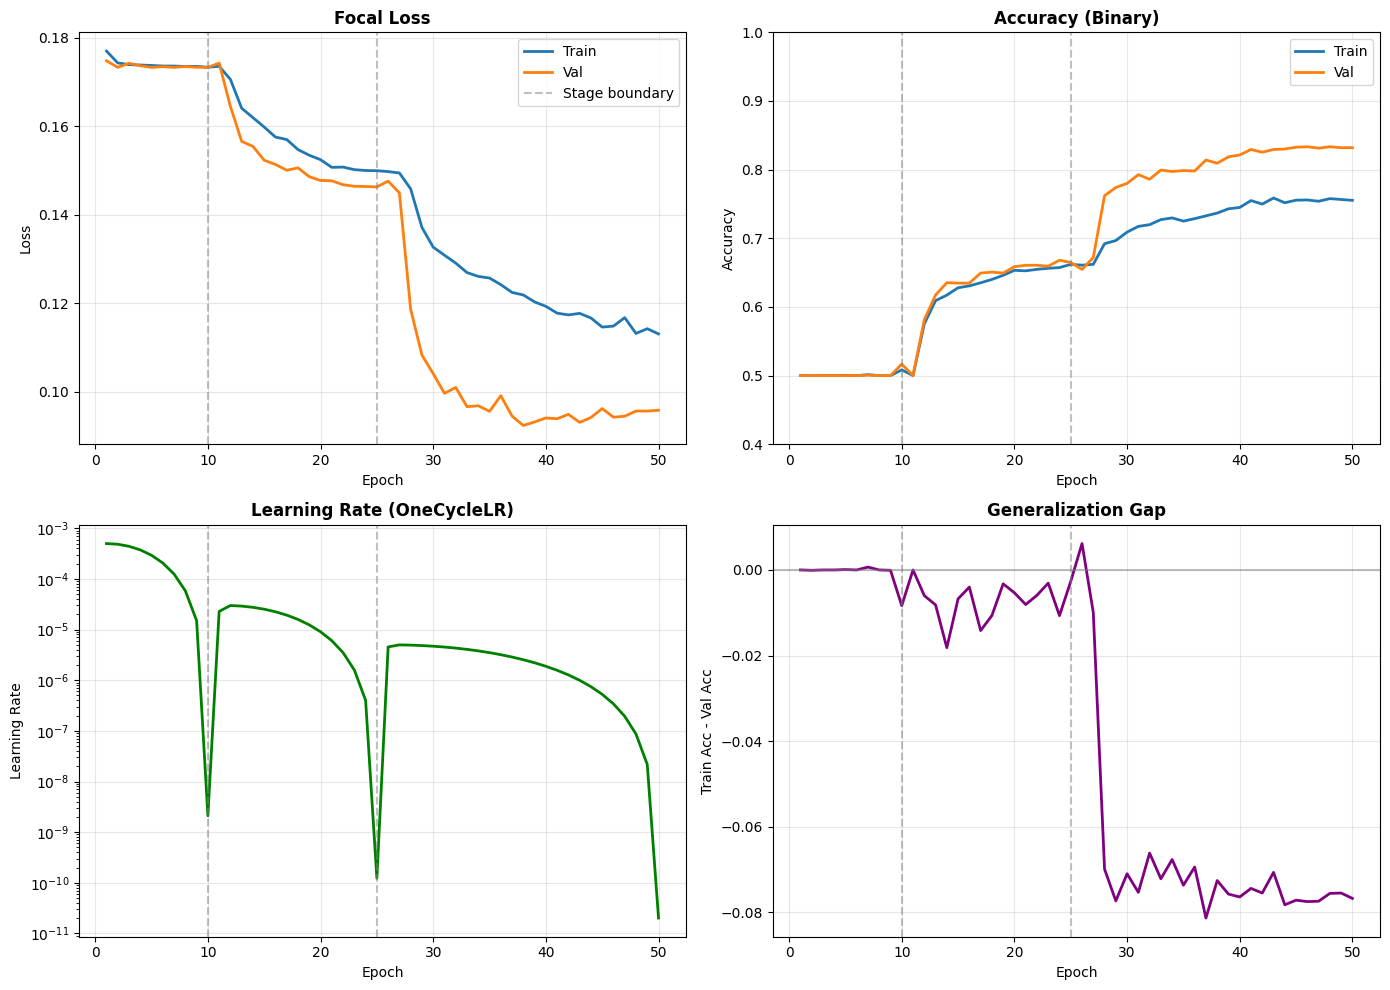

In [15]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], label='Val', linewidth=2)
axes[0, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5, label='Stage boundary')
axes[0, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Focal Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], label='Val', linewidth=2)
axes[0, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy (Binary)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# Learning rate
axes[1, 0].plot(epochs, history['lr'], linewidth=2, color='green')
axes[1, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Generalization gap
gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Generalization Gap', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/production/training_curves_dit_binary_15k.png', dpi=150)
plt.show()


CONFUSION MATRIX


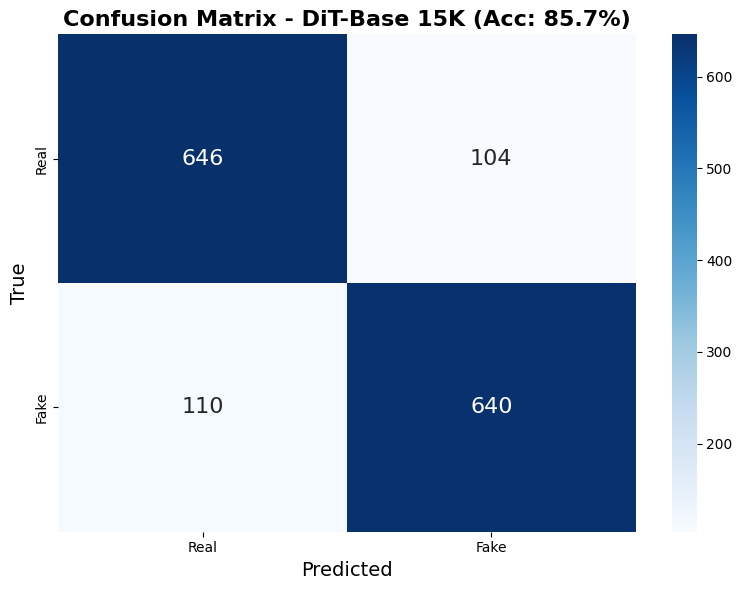


Classification Report:
              precision    recall  f1-score   support

        Real       0.85      0.86      0.86       750
        Fake       0.86      0.85      0.86       750

    accuracy                           0.86      1500
   macro avg       0.86      0.86      0.86      1500
weighted avg       0.86      0.86      0.86      1500



In [16]:
# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
labels = ['Real', 'Fake']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title(f'Confusion Matrix - DiT-Base 15K (Acc: {test_metrics["acc"]*100:.1f}%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/production/confusion_matrix_dit_binary_15k.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

## Save Model

In [17]:
import pickle
import shutil

notebook_dir = "notebooks/drivers_license_forgery/production"
model_path = os.path.join(notebook_dir, "dit_binary_15k.pth")

# Check disk space
disk = shutil.disk_usage(notebook_dir)
free_gb = disk.free / (1024**3)
print(f"Disk space available: {free_gb:.1f} GB")

if free_gb < 0.5:
    print("WARNING: Low disk space! Saving to /tmp/ instead")
    model_path = "/tmp/dit_binary_15k.pth"

# Save best model (move tensors to CPU first)
try:
    if best_model_state is not None:
        cpu_state = {k: v.cpu() for k, v in best_model_state.items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
        print(f"  Best epoch: {best_epoch}")
        print(f"  Best val acc: {best_val_acc:.4f}")
        print(f"  Test acc: {test_metrics['acc']:.4f}")
        print(f"  Test acc (TTA): {test_metrics_tta['acc']:.4f}")
    else:
        cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Save failed: {e}")
    fallback = "/tmp/dit_binary_15k.pth"
    cpu_state = {k: v.cpu() for k, v in (best_model_state or model.state_dict()).items()}
    torch.save(cpu_state, fallback)
    print(f"Saved to fallback: {fallback}")

# Save training history
history_path = os.path.join(notebook_dir, "training_history_dit_binary_15k.pkl")
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"Training history saved to: {history_path}")

# Verify file size
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {size_mb:.1f} MB")

Disk space available: 8.2 GB
Model saved to: notebooks/drivers_license_forgery/production/dit_binary_15k.pth
  Best epoch: 45
  Best val acc: 0.8327
  Test acc: 0.8573
  Test acc (TTA): 0.8507
Training history saved to: notebooks/drivers_license_forgery/production/training_history_dit_binary_15k.pkl
Model file size: 328.6 MB


## Out-of-Dataset Evaluation (test_samples.json)

In [18]:
import json

# Auto-reload if needed (for running this cell in a fresh kernel)
if 'tta_transforms' not in dir():
    print("Reloading transforms...")
    tta_transforms = [
        A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(0.95, 0.95), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(1.05, 1.05), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
    ]

def predict_single(image_path, model, device):
    """Predict on a single image with TTA"""
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for transform in tta_transforms:
            transformed = transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    
    avg_probs = torch.stack(all_probs).mean(dim=0)
    pred = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred].item()
    
    return pred, confidence

# Load test samples
samples_path = os.path.join(project_root, "notebooks/drivers_license_forgery/experiments/test_samples.json")
with open(samples_path) as f:
    samples = json.load(f)

print(f"\n{'='*70}")
print(f"OUT-OF-DATASET EVALUATION ({len(samples)} unseen samples)")
print(f"{'='*70}")

true_labels, pred_labels, details = [], [], []
skipped = 0

for s in tqdm(samples, desc="Evaluating"):
    img_path = os.path.join(project_root, s['path'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    pred_idx, confidence = predict_single(img_path, model, device)
    true_idx = s['is_fake']
    pred_label = "Fake" if pred_idx == 1 else "Real"
    true_label = s['expected_binary']

    true_labels.append(true_idx)
    pred_labels.append(pred_idx)
    details.append({
        'path': s['path'],
        'country': s['country'],
        'fraud_type': s['fraud_type'],
        'true': true_label,
        'pred': pred_label,
        'confidence': confidence,
        'correct': pred_label == true_label
    })

if skipped:
    print(f"Skipped {skipped} (file not found)")

# Results
correct = sum(d['correct'] for d in details)
total = len(details)
accuracy = correct / total

print(f"\nOverall Accuracy: {accuracy:.4f} ({correct}/{total})")

# Per class
print(f"\nPer Class:")
for label in ['Real', 'Fake']:
    subset = [d for d in details if d['true'] == label]
    acc = sum(d['correct'] for d in subset) / len(subset)
    avg_conf = sum(d['confidence'] for d in subset) / len(subset)
    print(f"  {label:5s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)}) avg conf: {avg_conf:.4f}")

# Per fraud type
print(f"\nPer Fraud Type:")
for ftype in ['real', 'face_morphing', 'face_replacement']:
    subset = [d for d in details if d['fraud_type'] == ftype]
    acc = sum(d['correct'] for d in subset) / len(subset)
    print(f"  {ftype:20s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Per country
print(f"\nPer Country:")
for country in ['DC', 'AZ', 'WV']:
    subset = [d for d in details if d['country'] == country]
    acc = sum(d['correct'] for d in subset) / len(subset)
    print(f"  {country}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Classification report
print(f"\n{'='*60}")
print(classification_report(true_labels, pred_labels, target_names=['Real', 'Fake']))

# Top 10 worst mistakes
print(f"\n{'='*60}")
print("TOP 10 WORST MISTAKES (lowest confidence correct or highest confidence wrong)")
print(f"{'='*60}")
wrong = [d for d in details if not d['correct']]
wrong_sorted = sorted(wrong, key=lambda x: x['confidence'], reverse=True)
for i, d in enumerate(wrong_sorted[:10]):
    print(f"  {i+1}. [{d['country']}] {d['fraud_type']:20s} | True: {d['true']:5s} | Pred: {d['pred']:5s} | Conf: {d['confidence']:.4f}")
    print(f"     {d['path']}")


OUT-OF-DATASET EVALUATION (999 unseen samples)


Evaluating: 100%|██████████| 999/999 [01:52<00:00,  8.84it/s]


Overall Accuracy: 0.8058 (805/999)

Per Class:
  Real : 0.8709 (290/333) avg conf: 0.6257
  Fake : 0.7733 (515/666) avg conf: 0.6909

Per Fraud Type:
  real                : 0.8709 (290/333)
  face_morphing       : 0.6486 (216/333)
  face_replacement    : 0.8979 (299/333)

Per Country:
  DC: 0.7538 (251/333)
  AZ: 0.6637 (221/333)
  WV: 1.0000 (333/333)

              precision    recall  f1-score   support

        Real       0.66      0.87      0.75       333
        Fake       0.92      0.77      0.84       666

    accuracy                           0.81       999
   macro avg       0.79      0.82      0.80       999
weighted avg       0.83      0.81      0.81       999


TOP 10 WORST MISTAKES (lowest confidence correct or highest confidence wrong)
  1. [AZ] real                 | True: Real  | Pred: Fake  | Conf: 0.7428
     datasets/idnet/AZ/positive/generated.photos_v3_0626181.png
  2. [AZ] real                 | True: Real  | Pred: Fake  | Conf: 0.6922
     datasets/idnet/AZ/p

In [19]:
# Summary
print("\n" + "="*70)
print("FINAL SUMMARY - DiT-Base Binary 15K")
print("="*70)
print(f"\nModel: DiT-Base (microsoft/dit-base) with MLP head")
print(f"Pre-training: IIT-CDIP (42M document images)")
print(f"Dataset: 15,000 images (12K train / 1.5K val / 1.5K test)")
print(f"Training: 3-stage (head -> last 4 blocks -> full), {len(history['train_loss'])} epochs")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"\nResults:")
print(f"  Best Val Accuracy:       {best_val_acc:.4f}")
print(f"  Test Accuracy (standard):{test_metrics['acc']:.4f}")
print(f"  Test Accuracy (TTA):     {test_metrics_tta['acc']:.4f}")
print(f"  Out-of-Dataset Accuracy: {accuracy:.4f}")


FINAL SUMMARY - DiT-Base Binary 15K

Model: DiT-Base (microsoft/dit-base) with MLP head
Pre-training: IIT-CDIP (42M document images)
Dataset: 15,000 images (12K train / 1.5K val / 1.5K test)
Training: 3-stage (head -> last 4 blocks -> full), 50 epochs
Loss: Focal Loss (gamma=2.0)

Results:
  Best Val Accuracy:       0.8327
  Test Accuracy (standard):0.8573
  Test Accuracy (TTA):     0.8507
  Out-of-Dataset Accuracy: 0.8058
